In [1]:
from pylab import *
import Fluid_CP as FCP
import Compressor_model_CP as CM
import compressor_model as cm
import plotDiag_Th_Ts as Diag
from scipy.optimize import minimize,NonlinearConstraint,check_grad


The following is our compressor model 

In [104]:
T_ev = 10
T_co = 40
DeltaT_sh = 4.0
DeltaT_sc = 4.0
D = 30.0              #mm
Fluid = "R1234yf"
param = [T_ev,T_co,DeltaT_sh,DeltaT_sc,D]
eta_is, m_dot = cm.recip_comp_corr_SP(param,Fluid)
print("eta_is:", eta_is)
print("Mass Flow:", m_dot, "kg/s")

eta_is: 0.6374133353999449
Mass Flow: 0.028768875172186726 kg/s


In [107]:
n = 15
T_evs = linspace(-10.,6.,n)
T_cos = linspace(44.,70.,n)

eta_iss = zeros((n,n))
m_dots = zeros((n,n))
for i in range(n):
    for j in range(n):
        param = [T_evs[i],T_cos[j],DeltaT_sh,DeltaT_sc,D]
        eta_iss[i,j], m_dots[i,j] = cm.recip_comp_corr_SP(param,"Propane")
        


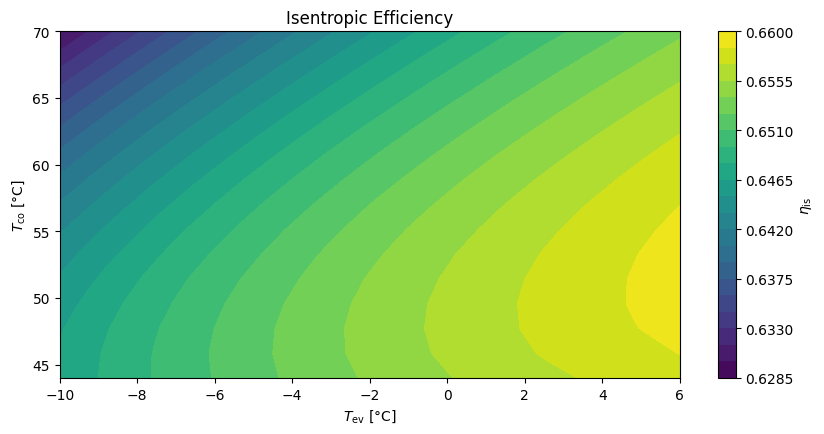

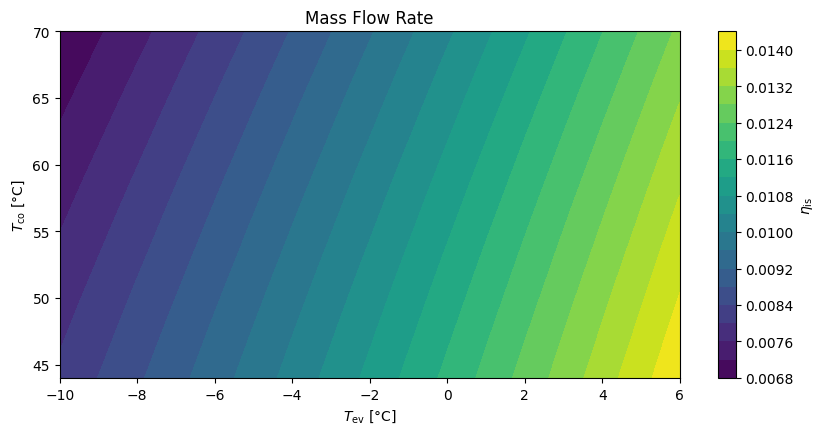

In [108]:
plt.figure(figsize=(10, 4.5))
contour_filled = plt.contourf(T_evs, T_cos, eta_iss.T, levels=20, cmap='viridis')
plt.colorbar(contour_filled, label="$\\eta_\\text{is}$")
plt.xlabel('$T_\\text{ev}$ [°C]')
plt.ylabel('$T_\\text{co}$ [°C]')
plt.title('Isentropic Efficiency')
plt.show()
plt.figure(figsize=(10, 4.5))
contour_filled = plt.contourf(T_evs, T_cos, m_dots.T, levels=20, cmap='viridis')
plt.colorbar(contour_filled, label="$\\eta_\\text{is}$")
plt.xlabel('$T_\\text{ev}$ [°C]')
plt.ylabel('$T_\\text{co}$ [°C]')
plt.title('Mass Flow Rate')
plt.show()

This to get the basic info for the fluid properties

In [5]:
print("Propane:")
print(FCP.get_fluid_info("Propane"))

print("R1234yf:")
print(FCP.get_fluid_info("R1234yf"))

print("Dimethyl ether(DME):")
print(FCP.get_fluid_info("DME"))

Propane:
molar_mass      0.044096
T_crit         96.740009
p_crit         42.511653
acentric        0.152100
T_min        -187.625000
T_max         376.850000
dtype: float64
R1234yf:
molar_mass      0.114042
T_crit         94.699989
p_crit         33.822449
acentric        0.276000
T_min         -53.150000
T_max         136.850000
dtype: float64
Dimethyl ether(DME):
molar_mass      0.046068
T_crit        127.228000
p_crit         53.366648
acentric        0.196000
T_min        -141.490000
T_max         251.850000
dtype: float64


$$\eta_{is} = \frac{h_{out,is}-h_{in}}{h_{out}-h_{in}}$$
$$h_{out}=h_{in}+\frac{h_{out,is}-h_{in}}{\eta_{is}}$$

In [6]:
T_ev = 5
DeltaT_sh = 5.0
DeltaT_sc = 5.0
Fluid = "Propane"
Eh = "CBar"
pressure_ratio = 3.0

state_1_x1 = FCP.state(["T","x"],[T_ev,1],Fluid,Eh)
state_1_sh = FCP.state(["T","p"],[T_ev+DeltaT_sh,state_1_x1["p"]],Fluid,Eh)
state_2_is = FCP.state(["p","s"],[state_1_x1["p"]*pressure_ratio,state_1_sh["s"]],Fluid,Eh)

h_2_vp = state_1_sh["h"] + (state_2_is["h"]-state_1_sh["h"])/eta_is

state_2_vp = FCP.state(["p","h"],[state_2_is["p"],h_2_vp],Fluid,Eh)
state_3_x0 = FCP.state(["p","x"],[state_2_is["p"],0],Fluid,Eh)
state_3_sc = FCP.state(["p","T"],[state_2_is["p"],state_3_x0["T"]-DeltaT_sc],Fluid,Eh)
state_4_xp = FCP.state(["h","p"],[state_3_sc["h"],state_1_x1["p"]],Fluid,Eh)

#print(state_1_x1)
#print(state_1_sh)
#print(state_2_is)
#print(state_2_vp)
#print(state_3_x0)
#print(state_3_sc)
#print(state_4_xp)

#Diag.Th(state_1_sh,state_2_vp,state_3_sc,state_4_xp,[32.0,32.0],[15.0,15.0],Fluid,Eh)

def ac_cycle(compressor_size, refrigerant):
    
    
    return None

In [92]:
DeltaT_sh = 4.0
DeltaT_sc = 4.0
Fluid = "R1234yf"
Eh = "CBar"
D = 30.0

In [93]:
def calc_COP(param):
    T_co,T_ev = param
    
    param_cm = [T_ev,T_co,DeltaT_sh,DeltaT_sc,D]
    eta_is, m_dot = cm.recip_comp_corr_SP(param_cm,Fluid)
    
    # State 1 sat vapor at evaporator
    state_1_x1 = FCP.state(["T","x"],[T_ev,1],Fluid,Eh)
    
    # State 1 superheating 
    state_1_sh = FCP.state(["T","p"],[T_ev+DeltaT_sh,state_1_x1["p"]],Fluid,Eh)
    
    # State 3 sat liquid at condensor
    state_3_x0 = FCP.state(["T","x"],[T_co,0],Fluid,Eh)
    
    # State 3 subcooled
    state_3_sc = FCP.state(["p","T"],[state_3_x0["p"],state_3_x0["T"]-DeltaT_sc],Fluid,Eh)
    
    # State 2 isentropic from state 1 superheating, State 2 on same isobar as state 3
    state_2_is = FCP.state(["p","s"],[state_3_x0["p"],state_1_sh["s"]],Fluid,Eh)
    
    # Specific enthalpy of state 2 vapor after compressor 
    h_2_vp = state_1_sh["h"] + (state_2_is["h"]-state_1_sh["h"])/eta_is
    
    # State 2 vapor after compressor
    state_2_vp = FCP.state(["p","h"],[state_2_is["p"],h_2_vp],Fluid,Eh)
    
    # State 4 after isenthalpic expansion vavle
    state_4_xp = FCP.state(["h","p"],[state_3_sc["h"],state_1_x1["p"]],Fluid,Eh)
    
    # All states are defined
    
    # spec. heat extracted in the evaporator from State 4 after expansion valve to Super heating State 1
    q_cool = state_1_sh["h"] - state_4_xp["h"]
    
    #spec. compressor work from superheated state 1 to vapor state 2 
    w_comp = state_2_vp["h"] - state_1_sh["h"]
    
    # Coefficient of Performance of AC unit
    COP = q_cool/w_comp
    
    # Return reciprocal value of COP
    return 1./COP

In [94]:
def calc_cooling_power(param):
    T_co,T_ev = param
    
    param_cm = [T_ev,T_co,DeltaT_sh,DeltaT_sc,D]
    eta_is, m_dot = cm.recip_comp_corr_SP(param_cm,Fluid) 
    
    # State 1 sat vapor at evaporator
    state_1_x1 = FCP.state(["T","x"],[T_ev,1],Fluid,Eh)
    
    # State 1 superheating 
    state_1_sh = FCP.state(["T","p"],[T_ev+DeltaT_sh,state_1_x1["p"]],Fluid,Eh)
    
    # State 3 sat liquid at condensor
    state_3_x0 = FCP.state(["T","x"],[T_co,0],Fluid,Eh)
    
    # State 3 subcooled
    state_3_sc = FCP.state(["p","T"],[state_3_x0["p"],state_3_x0["T"]-DeltaT_sc],Fluid,Eh)
    
    # State 2 isentropic from state 1 superheating, State 2 on same isobar as state 3
    state_2_is = FCP.state(["p","s"],[state_3_x0["p"],state_1_sh["s"]],Fluid,Eh)
    
    # Specific enthalpy of state 2 vapor after compressor 
    h_2_vp = state_1_sh["h"] + (state_2_is["h"]-state_1_sh["h"])/eta_is
    
    # State 2 vapor after compressor
    state_2_vp = FCP.state(["p","h"],[state_2_is["p"],h_2_vp],Fluid,Eh)
    
    # State 4 after isenthalpic expansion vavle
    state_4_xp = FCP.state(["h","p"],[state_3_sc["h"],state_1_x1["p"]],Fluid,Eh)
    
    q_cool = state_1_sh["h"] - state_4_xp["h"] # kJ/kg
    
    Q_cool = m_dot * q_cool # kg/s * kJ/kg = kW
    
    return Q_cool

In [95]:
def calc_pressure_ratio(param):
    T_co,T_ev = param
    
    # State 1 sat vapor at evaporator
    state_1_x1 = FCP.state(["T","x"],[T_ev,1],Fluid,Eh)
     
    # State 3 sat liquid at condensor
    state_3_x0 = FCP.state(["T","x"],[T_co,0],Fluid,Eh)
    
    pressure_ratio = state_3_x0["p"]/state_1_x1["p"]
    
    return pressure_ratio

In [99]:
#Syntax: bounds=[(T_co_min, T_co_max), (T_ev_min, T_ev_max)]
bounds = [(35+5+DeltaT_sc,70),(-20.0,15-5-DeltaT_sh)]

minimum_cooling_power = 0
minimum_pressure_ratio = 2.0

NC1 = NonlinearConstraint(calc_cooling_power, minimum_cooling_power, np.inf)
NC2 = NonlinearConstraint(calc_pressure_ratio, minimum_pressure_ratio, np.inf)
NCs = (NC1,NC2)

In [100]:
#Define an appropriate initial guess (starting point).
T_co_start=50. #°C
T_ev_start=0. #°C

#Use minimize to optimize the COP
Opti=minimize(calc_COP,x0=[T_co_start,T_ev_start],method='SLSQP',bounds=bounds,constraints=NCs)

#Check if the optimization terminated successfull and print the COP
print("Success optimization=",Opti.success)

Success optimization= True


In [101]:
print(Opti)
COP = 1./calc_COP(Opti.x)

print("optimized COP = ",round(COP,2))
#Print the optimized evaporator and condenser temperature: T_ev_op, T_co_op
T_ev_op=Opti.x[1]
T_co_op=Opti.x[0]


param = [T_ev_op,T_co_op,DeltaT_sh,DeltaT_sc,D]
eta_is, m_dot = cm.recip_comp_corr_SP(param,Fluid)
cooling_power = calc_cooling_power([T_co_op,T_ev_op])
pressure_ratio = calc_pressure_ratio([T_co_op,T_ev_op])

print("optimized mass flow rate= ",round(m_dot,5),"kg/s")
print("optimized isentropic efficiency= ",round(eta_is,5))
print("optimized cooling power= ",round(cooling_power,5),"kW")
print("optimized pressure ratio= ",round(pressure_ratio,5))

print("optimized condensation temperature= ",round(T_co_op,2),"°C")
print("optimized evaporation temperature= ",round(T_ev_op,2),"°C")
print("Compressor Diameter= ",D,"mm")
print("Fluid= ",Fluid)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.2612768483777256
           x: [ 4.400e+01  6.000e+00]
         nit: 9
         jac: [ 8.628e-03 -9.543e-03]
        nfev: 27
        njev: 9
 multipliers: [ 0.000e+00  0.000e+00]
optimized COP =  3.83
optimized mass flow rate=  0.02451 kg/s
optimized isentropic efficiency=  0.64365
optimized cooling power=  2.84624 kW
optimized pressure ratio=  2.92225
optimized condensation temperature=  44.0 °C
optimized evaporation temperature=  6.0 °C
Compressor Diameter=  30.0 mm
Fluid=  R1234yf


In [28]:
state_1_x1 = FCP.state(["T","x"],[T_ev_op,1],Fluid,Eh)
state_1_sh = FCP.state(["T","p"],[T_ev_op+DeltaT_sh,state_1_x1["p"]],Fluid,Eh)



state_3_x0 = FCP.state(["T","x"],[T_co_op,0],Fluid,Eh)

state_2_is = FCP.state(["p","s"],[state_3_x0["p"],state_1_sh["s"]],Fluid,Eh)

h_2_vp = state_1_sh["h"] + (state_2_is["h"]-state_1_sh["h"])/eta_is
state_2_vp = FCP.state(["p","h"],[state_2_is["p"],h_2_vp],Fluid,Eh)

state_3_sc = FCP.state(["T","p"],[T_co_op-DeltaT_sc,state_3_x0["p"]],Fluid,Eh)
state_4_xp = FCP.state(["h","p"],[state_3_sc["h"],state_1_x1["p"]],Fluid,Eh)

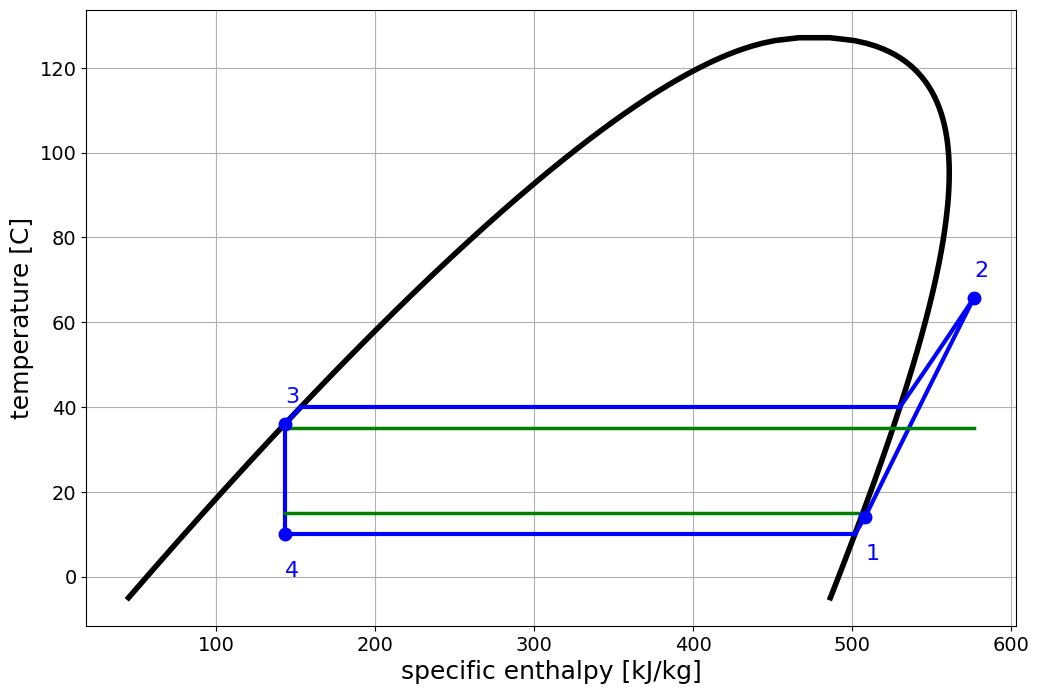

In [29]:
Diag.Th(state_1_sh,state_2_vp,state_3_sc,state_4_xp, [35.0,35.0], [15.0,15.0], Fluid, Eh)